# 03b - Advanced Parcellation

This notebook extends the project from 3-class tissue segmentation to **133-label whole-brain parcellation**.

Although a Swin UNETR checkpoint would be a natural candidate, the current official MONAI bundle that best matches this task is **`wholeBrainSeg_Large_UNEST_segmentation`**. It is a transformer-based whole-brain model that predicts 133 anatomical structures, including the hippocampus, amygdala, thalamus, caudate, ventricles, and many cortical regions.

Important constraint: the official MONAI bundle expects the input T1 MRI to be affinely registered to **MNI305** space before inference. This notebook performs that registration first, runs MONAI sliding-window inference, and then maps the predicted label map back into the native space of `brain_stripped.nii.gz`.

**Main outputs**
- `outputs/segmentations/advanced_parcellation.nii.gz` - 133-label native-space parcellation
- `outputs/segmentations/advanced_parcellation_mni305.nii.gz` - label map in MNI305 space
- `outputs/figures/03b_advanced_parcellation_overlay.png` - overlay of selected subcortical structures


In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import SimpleITK as sitk
import torch
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from monai.bundle import download as download_bundle
from monai.inferers import SlidingWindowInferer
from monai.transforms import (
    Compose,
    EnsureChannelFirstd,
    EnsureTyped,
    LoadImaged,
    NormalizeIntensityd,
    SpatialPadd,
)
from templateflow.api import get as tflow_get

warnings.filterwarnings("ignore", message=r".*torch.meshgrid.*")
warnings.filterwarnings(
    "ignore",
    message=r"Using a non-tuple sequence for multidimensional indexing is deprecated.*",
)

In [2]:
# -- Paths ------------------------------------------------------------------
CWD = Path.cwd().resolve()
ROOT = CWD if (CWD / "data").exists() and (CWD / "outputs").exists() else CWD.parent
assert (ROOT / "data").exists(), f"Could not locate project root from {CWD}"

PROC = ROOT / "data" / "processed"
SEG = ROOT / "outputs" / "segmentations"
FIG = ROOT / "outputs" / "figures"
BUNDLE_DIR = ROOT / "models" / "monai_bundles"

INPUT_PATH = PROC / "brain_stripped.nii.gz"
MNI_REGISTERED_PATH = PROC / "brain_stripped_mni305_affine.nii.gz"
AFFINE_TRANSFORM_PATH = PROC / "brain_stripped_to_mni305.tfm"
REGISTERED_LABELMAP_PATH = SEG / "advanced_parcellation_mni305.nii.gz"
OUTPUT_LABELMAP_PATH = SEG / "advanced_parcellation.nii.gz"
FIGURE_PATH = FIG / "03b_advanced_parcellation_overlay.png"

for path in [SEG, FIG, BUNDLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

assert INPUT_PATH.exists(), f"Missing input volume: {INPUT_PATH}"
print("Project root:", ROOT)
print("Input scan  :", INPUT_PATH)

Project root: /Users/willhawe/Documents/BrainScan
Input scan  : /Users/willhawe/Documents/BrainScan/data/processed/brain_stripped.nii.gz


## Step 1 - Download the official MONAI bundle and inspect the label space

We use MONAI's bundle API to download the pretrained `wholeBrainSeg_Large_UNEST_segmentation` package. The bundle metadata provides the 133-label lookup table, which we will reuse for visualization and interpretation.

In [3]:
BUNDLE_NAME = "wholeBrainSeg_Large_UNEST_segmentation"
BUNDLE_ROOT = BUNDLE_DIR / BUNDLE_NAME

if not BUNDLE_ROOT.exists():
    print(f"Downloading MONAI bundle: {BUNDLE_NAME}")
    download_bundle(name=BUNDLE_NAME, bundle_dir=str(BUNDLE_DIR), source="monaihosting", progress=True)
else:
    print("Reusing cached MONAI bundle.")

metadata_path = BUNDLE_ROOT / "configs" / "metadata.json"
inference_config_path = BUNDLE_ROOT / "configs" / "inference.json"

metadata = json.loads(metadata_path.read_text())
inference_config = json.loads(inference_config_path.read_text())
label_lookup = {
    int(k): v for k, v in metadata["network_data_format"]["outputs"]["pred"]["channel_def"].items()
}

selected_groups = {
    "Hippocampus": [idx for idx, name in label_lookup.items() if "Hippocampus" in name],
    "Amygdala": [idx for idx, name in label_lookup.items() if "Amygdala" in name],
    "Thalamus": [idx for idx, name in label_lookup.items() if "Thalamus-Proper" in name],
    "Caudate": [idx for idx, name in label_lookup.items() if "Caudate" in name],
}

summary_rows = []
for group, ids in selected_groups.items():
    for idx in ids:
        summary_rows.append({"group": group, "label_id": idx, "label_name": label_lookup[idx]})

print("Bundle root :", BUNDLE_ROOT)
print("Bundle name :", metadata["name"])
print("Task        :", metadata["task"])
print("Pred classes:", metadata["pred_classes"])
print("ROI size    :", tuple(inference_config["inferer"]["roi_size"]))

pd.DataFrame(summary_rows)

Reusing cached MONAI bundle.
Bundle root : /Users/willhawe/Documents/BrainScan/models/monai_bundles/wholeBrainSeg_Large_UNEST_segmentation
Bundle name : Whole Brain Large UNEST Segmentation
Task        : Whole Brain Segmentation in T1W MRI
Pred classes: 133 Classes
ROI size    : (96, 96, 96)


,group,label_id,label_name
0,Hippocampus,16,Right-Hippocampus
1,Hippocampus,17,Left-Hippocampus
2,Amygdala,5,Right-Amygdala
3,Amygdala,6,Left-Amygdala
4,Thalamus,26,Right-Thalamus-Proper
5,Thalamus,27,Left-Thalamus-Proper
6,Caudate,8,Right-Caudate
7,Caudate,9,Left-Caudate


## Step 2 - Fetch the MNI305 template and affinely register the input scan

The MONAI bundle expects MNI305-aligned T1 MRI as input. We download the official `MNI305` template and brain mask via TemplateFlow, then compute an affine transform with SimpleITK.

The registered image is cached locally so the registration does not need to rerun on every notebook execution.

In [4]:
def strip_with_mask(image, mask):
    mask = sitk.Cast(mask > 0, sitk.sitkUInt8)
    return sitk.Mask(image, mask)


def run_affine_registration(fixed_image, moving_image):
    initial_transform = sitk.CenteredTransformInitializer(
        fixed_image,
        moving_image,
        sitk.AffineTransform(3),
        sitk.CenteredTransformInitializerFilter.GEOMETRY,
    )

    registration = sitk.ImageRegistrationMethod()
    registration.SetMetricAsMattesMutualInformation(numberOfHistogramBins=32)
    registration.SetMetricSamplingStrategy(registration.RANDOM)
    registration.SetMetricSamplingPercentage(0.2)
    registration.SetInterpolator(sitk.sitkLinear)
    registration.SetOptimizerAsGradientDescent(
        learningRate=1.0,
        numberOfIterations=250,
        convergenceMinimumValue=1e-6,
        convergenceWindowSize=10,
    )
    registration.SetOptimizerScalesFromPhysicalShift()
    registration.SetShrinkFactorsPerLevel([4, 2, 1])
    registration.SetSmoothingSigmasPerLevel([2, 1, 0])
    registration.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()
    registration.SetInitialTransform(initial_transform, inPlace=False)

    return registration.Execute(fixed_image, moving_image)


template_t1_path = Path(tflow_get("MNI305", suffix="T1w"))
template_mask_path = Path(tflow_get("MNI305", suffix="mask", desc="brain"))

fixed_t1 = sitk.ReadImage(str(template_t1_path), sitk.sitkFloat32)
fixed_mask = sitk.ReadImage(str(template_mask_path), sitk.sitkUInt8)
fixed_brain = strip_with_mask(fixed_t1, fixed_mask)
moving_brain = sitk.ReadImage(str(INPUT_PATH), sitk.sitkFloat32)

if MNI_REGISTERED_PATH.exists() and AFFINE_TRANSFORM_PATH.exists():
    transform = sitk.ReadTransform(str(AFFINE_TRANSFORM_PATH))
    registered_brain = sitk.ReadImage(str(MNI_REGISTERED_PATH), sitk.sitkFloat32)
    print("Reusing cached MNI305 registration.")
else:
    print("Running affine registration to MNI305...")
    transform = run_affine_registration(fixed_brain, moving_brain)
    registered_brain = sitk.Resample(
        moving_brain,
        fixed_brain,
        transform,
        sitk.sitkLinear,
        0.0,
        sitk.sitkFloat32,
    )
    sitk.WriteImage(registered_brain, str(MNI_REGISTERED_PATH))
    sitk.WriteTransform(transform, str(AFFINE_TRANSFORM_PATH))
    print("Saved registered image :", MNI_REGISTERED_PATH)
    print("Saved affine transform :", AFFINE_TRANSFORM_PATH)

print("Template T1   :", template_t1_path)
print("Template mask :", template_mask_path)
print("Registered XYZ shape:", sitk.GetArrayFromImage(registered_brain).shape[::-1])

Reusing cached MNI305 registration.
Template T1   : /Users/willhawe/Library/Caches/templateflow/tpl-MNI305/tpl-MNI305_T1w.nii.gz
Template mask : /Users/willhawe/Library/Caches/templateflow/tpl-MNI305/tpl-MNI305_desc-brain_mask.nii.gz
Registered XYZ shape: (172, 220, 156)


## Step 3 - Build the MONAI preprocessing pipeline

The official inference config uses channel-first formatting plus nonzero intensity normalization. We keep that logic, and add a small spatial pad so the scan is guaranteed to be compatible with the bundle's 96 x 96 x 96 sliding-window ROI.

In [5]:
preprocess = Compose(
    [
        LoadImaged(keys="image", image_only=False),
        EnsureChannelFirstd(keys="image"),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        SpatialPadd(keys="image", spatial_size=(96, 96, 96), method="end"),
        EnsureTyped(keys="image"),
    ]
)

batch = preprocess({"image": str(MNI_REGISTERED_PATH)})
image = batch["image"].unsqueeze(0)
registered_shape = nib.load(str(MNI_REGISTERED_PATH)).shape

print("Tensor shape after preprocessing :", tuple(image.shape))
print("Registered NIfTI shape           :", registered_shape)
print("Tensor dtype                     :", image.dtype)

Tensor shape after preprocessing : (1, 1, 172, 220, 156)
Registered NIfTI shape           : (172, 220, 156)
Tensor dtype                     : torch.float32


## Step 4 - Instantiate the 133-label transformer model and inferer

The bundle's network definition is a large UNesT model. We import its architecture from the downloaded bundle, load the pretrained checkpoint, and configure MONAI's `SlidingWindowInferer` for memory-safe inference.

On Apple Silicon, this model is typically too large for the `mps` backend. The notebook therefore prefers **CUDA if available, otherwise CPU**.

In [6]:
# CUDA is the only accelerated backend we use for this bundle.
# Apple MPS frequently runs out of memory with this 133-label transformer model,
# so we fall back to CPU when CUDA is unavailable.
if torch.cuda.is_available():
    device = torch.device("cuda")
    stitch_device = torch.device("cpu")
else:
    device = torch.device("cpu")
    stitch_device = torch.device("cpu")

if str(BUNDLE_ROOT) not in sys.path:
    sys.path.insert(0, str(BUNDLE_ROOT))

from scripts.networks.unest_base_patch_4 import UNesT

network_def = inference_config["network_def"]
roi_size = tuple(inference_config["inferer"]["roi_size"])

model = UNesT(
    in_channels=network_def["in_channels"],
    out_channels=network_def["out_channels"],
    patch_size=network_def["patch_size"],
    depths=tuple(network_def["depths"]),
    embed_dim=tuple(network_def["embed_dim"]),
    num_heads=tuple(network_def["num_heads"]),
).to(device)

checkpoint_path = BUNDLE_ROOT / "models" / "model.pt"
try:
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
except TypeError:
    checkpoint = torch.load(checkpoint_path, map_location=device)

state_dict = checkpoint["model"] if isinstance(checkpoint, dict) and "model" in checkpoint else checkpoint
model.load_state_dict(state_dict, strict=True)
model.eval()

sw_batch_size = 4 if device.type == "cuda" else 1
inferer = SlidingWindowInferer(
    roi_size=roi_size,
    sw_batch_size=sw_batch_size,
    overlap=0.7,
    mode="gaussian",
    sw_device=device,
    device=stitch_device,
    progress=True,
)

print("Device        :", device)
print("Stitch device :", stitch_device)
print("Checkpoint    :", checkpoint_path)
print("ROI size      :", roi_size)
print("SW batch size :", sw_batch_size)

Device        : cpu
Stitch device : cpu
Checkpoint    : /Users/willhawe/Documents/BrainScan/models/monai_bundles/wholeBrainSeg_Large_UNEST_segmentation/models/model.pt
ROI size      : (96, 96, 96)
SW batch size : 1


## Step 5 - Run inference, collapse channels to labels, and save the parcellation

The network outputs 133 class channels. We apply softmax, take the `argmax` across channels to get a single label per voxel, save the result in MNI305 space, and then resample the label map back into the native space of the skull-stripped input scan.

Because the bundle predicts a complete MNI305 brain parcellation, the inverse-resampled label map can spill slightly outside the skull-stripped native brain. We therefore apply the original skull-stripping mask before saving the final native-space output.

In [7]:
inputs = image.to(device=device, dtype=torch.float32)

with torch.no_grad():
    logits = inferer(inputs, model)
    probabilities = torch.softmax(logits, dim=1)
    prediction = torch.argmax(probabilities, dim=1).squeeze(0).cpu().numpy().astype(np.uint16)

del logits, probabilities

# Remove any padding that may have been added for small volumes.
prediction = prediction[: registered_shape[0], : registered_shape[1], : registered_shape[2]]

registered_ref = nib.load(str(MNI_REGISTERED_PATH))
registered_header = registered_ref.header.copy()
registered_header.set_data_dtype(np.uint16)
nib.save(
    nib.Nifti1Image(prediction, registered_ref.affine, registered_header),
    str(REGISTERED_LABELMAP_PATH),
)

registered_label_sitk = sitk.ReadImage(str(REGISTERED_LABELMAP_PATH), sitk.sitkUInt16)
native_reference = sitk.ReadImage(str(INPUT_PATH), sitk.sitkFloat32)
native_label_sitk = sitk.Resample(
    registered_label_sitk,
    native_reference,
    transform.GetInverse(),
    sitk.sitkNearestNeighbor,
    0,
    sitk.sitkUInt16,
)

native_label_arr = sitk.GetArrayFromImage(native_label_sitk)
native_label_arr = np.transpose(native_label_arr, (2, 1, 0))
brain_mask = nib.load(str(PROC / "brain_stripped_mask.nii.gz")).get_fdata() > 0.5
removed_outside_mask = int(((native_label_arr > 0) & (~brain_mask)).sum())
native_label_arr[~brain_mask] = 0

native_ref_nib = nib.load(str(INPUT_PATH))
native_header = native_ref_nib.header.copy()
native_header.set_data_dtype(np.uint16)
nib.save(
    nib.Nifti1Image(native_label_arr.astype(np.uint16), native_ref_nib.affine, native_header),
    str(OUTPUT_LABELMAP_PATH),
)

parcellation = np.asarray(nib.load(str(OUTPUT_LABELMAP_PATH)).get_fdata(), dtype=np.uint16)
unique_nonzero = np.unique(parcellation[parcellation > 0])

print("Saved registered label map :", REGISTERED_LABELMAP_PATH)
print("Saved native-space labels  :", OUTPUT_LABELMAP_PATH)
print("Removed outside-mask voxels:", removed_outside_mask)
print("Non-background labels used :", len(unique_nonzero))
print("First 20 predicted labels  :", unique_nonzero[:20].tolist())

100%|█████████████████████████████████████████████████████████████| 96/96 [08:09<00:00,  5.10s/it]


Saved registered label map : /Users/willhawe/Documents/BrainScan/outputs/segmentations/advanced_parcellation_mni305.nii.gz
Saved native-space labels  : /Users/willhawe/Documents/BrainScan/outputs/segmentations/advanced_parcellation.nii.gz
Removed outside-mask voxels: 901707
Non-background labels used : 132
First 20 predicted labels  : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


## Step 6 - Visualize selected subcortical structures

A full 133-label overlay is too dense to interpret on a single figure, so the visualization focuses on a few anatomically interesting bilateral structures:
- Hippocampus
- Amygdala
- Thalamus
- Caudate

The slices are chosen around the center of mass of the highlighted structures so the overlay is more informative than a simple middle slice.

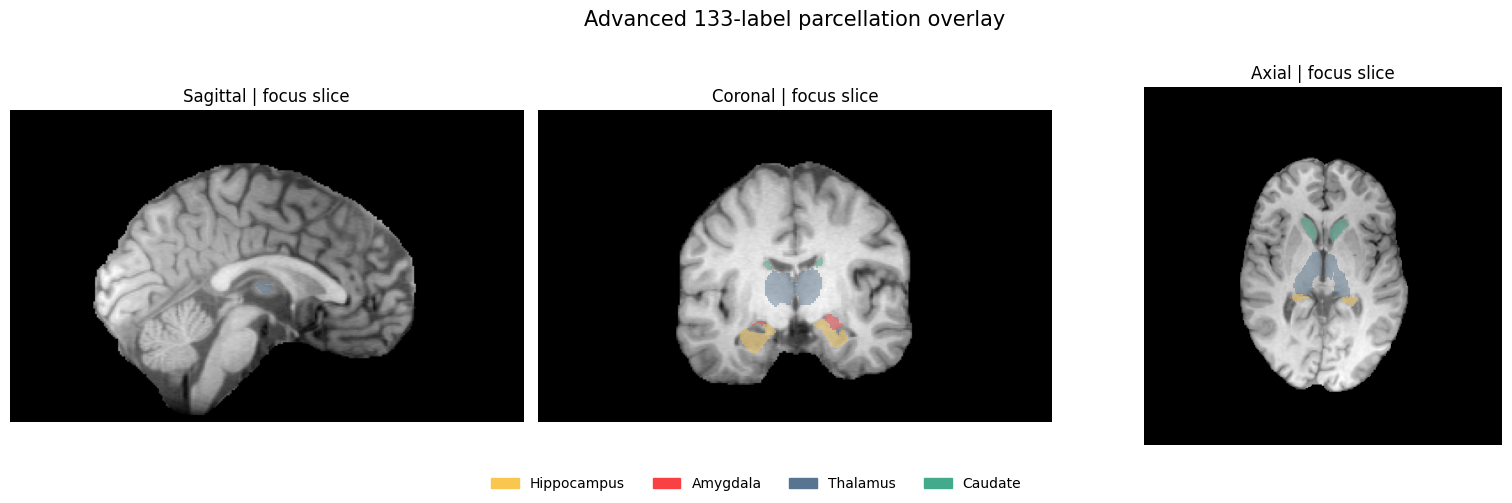

In [8]:
scan = np.asarray(nib.load(str(INPUT_PATH)).get_fdata(), dtype=np.float32)
label_map = np.asarray(nib.load(str(OUTPUT_LABELMAP_PATH)).get_fdata(), dtype=np.uint16)

highlight_colors = {
    "Hippocampus": "#f9c74f",
    "Amygdala": "#f94144",
    "Thalamus": "#577590",
    "Caudate": "#43aa8b",
}

focus_labels = sorted({idx for ids in selected_groups.values() for idx in ids})
focus_mask = np.isin(label_map, focus_labels)

if focus_mask.any():
    x_idx, y_idx, z_idx = np.round(np.argwhere(focus_mask).mean(axis=0)).astype(int).tolist()
else:
    x_idx, y_idx, z_idx = [s // 2 for s in label_map.shape]


def rotated_slice(volume, plane, x, y, z):
    if plane == "Sagittal":
        return np.rot90(volume[x, :, :])
    if plane == "Coronal":
        return np.rot90(volume[:, y, :])
    return np.rot90(volume[:, :, z])


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
planes = ["Sagittal", "Coronal", "Axial"]

for ax, plane in zip(axes, planes):
    ax.imshow(rotated_slice(scan, plane, x_idx, y_idx, z_idx), cmap="gray")

    for structure, color in highlight_colors.items():
        structure_mask = np.isin(label_map, selected_groups[structure]).astype(np.uint8)
        overlay = rotated_slice(structure_mask, plane, x_idx, y_idx, z_idx)
        overlay = np.ma.masked_where(overlay == 0, overlay)
        ax.imshow(
            overlay,
            cmap=ListedColormap([color]),
            alpha=0.45,
            interpolation="none",
            vmin=0,
            vmax=1,
        )

    ax.set_title(f"{plane} | focus slice")
    ax.axis("off")

legend_handles = [Patch(color=color, label=structure) for structure, color in highlight_colors.items()]
fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=False)
fig.suptitle("Advanced 133-label parcellation overlay", fontsize=15)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
fig.savefig(FIGURE_PATH, dpi=150, bbox_inches="tight")
plt.show()

In [9]:
voxel_volume_mm3 = float(np.prod(nib.load(str(INPUT_PATH)).header.get_zooms()[:3]))

rows = []
for structure, ids in selected_groups.items():
    mask = np.isin(label_map, ids)
    rows.append(
        {
            "structure_group": structure,
            "label_ids": ids,
            "voxel_count": int(mask.sum()),
            "volume_mm3": float(mask.sum() * voxel_volume_mm3),
        }
    )

summary_df = pd.DataFrame(rows)

print("Saved native-space parcellation:", OUTPUT_LABELMAP_PATH)
print("Saved overlay figure          :", FIGURE_PATH)
summary_df

Saved native-space parcellation: /Users/willhawe/Documents/BrainScan/outputs/segmentations/advanced_parcellation.nii.gz
Saved overlay figure          : /Users/willhawe/Documents/BrainScan/outputs/figures/03b_advanced_parcellation_overlay.png


,structure_group,label_ids,voxel_count,volume_mm3
0,Hippocampus,"[16, 17]",8280,8280.0
1,Amygdala,"[5, 6]",2484,2484.0
2,Thalamus,"[26, 27]",15975,15975.0
3,Caudate,"[8, 9]",8116,8116.0
